In [3]:
!pip install xarray numpy matplotlib cartopy scipy pandas netCDF4

In [5]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy import stats
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

# ─── 1. LOAD ───────────────────────────────────────────────────────────────
files = [
    "D:/ex03/era5_hourly_onsingle_1950-1970_2m_temperature.nc",
    "D:/ex03/era5_hourly_onsingle_1970_1990_2m_temperature.nc",
    "D:/ex03/era5_hourly_onsingle_1991_2010_2m_temperature.nc",
    "D:/ex03/era5_hourly_onsingle_2011-2024_2m_temperature.nc",
]

print("Loading files...")
datasets = []
for f in files:
    ds = xr.open_dataset(f)
    print(f"  {f.split('/')[-1]}: {ds['valid_time'].values[0]} → {ds['valid_time'].values[-1]}")
    datasets.append(ds)

Loading files...
  era5_hourly_onsingle_1950-1970_2m_temperature.nc: 1950-01-01T06:00:00.000000000 → 1970-12-31T18:00:00.000000000
  era5_hourly_onsingle_1970_1990_2m_temperature.nc: 1970-01-01T06:00:00.000000000 → 1990-12-31T18:00:00.000000000
  era5_hourly_onsingle_1991_2010_2m_temperature.nc: 1991-01-01T06:00:00.000000000 → 2010-12-31T18:00:00.000000000
  era5_hourly_onsingle_2011-2024_2m_temperature.nc: 2011-01-01T06:00:00.000000000 → 2024-12-31T18:00:00.000000000


In [6]:
# ─── 2. COMBINE ────────────────────────────────────────────────────────────
print("\nCombining...")
ds_all = xr.concat(datasets, dim="valid_time")
ds_all = ds_all.sortby("valid_time")
ds_all = ds_all.drop_duplicates("valid_time")

print(f"Combined shape: {ds_all['t2m'].shape}")
print(f"Unique hours: {np.unique(ds_all['valid_time'].dt.hour.values)}")


Combining...
Combined shape: (54788, 169, 241)
Unique hours: [ 6 18]


In [7]:
# ─── 3. SEPARATE 06 AND 18 ─────────────────────────────────────────────────
print("\nSeparating 06:00 and 18:00...")
t2m_c = ds_all["t2m"] - 273.15

t_night = t2m_c.sel(valid_time=t2m_c.valid_time.dt.hour == 6)   # night proxy
t_day   = t2m_c.sel(valid_time=t2m_c.valid_time.dt.hour == 18)  # day proxy

print(f"Night (06:00) steps: {len(t_night.valid_time)}")
print(f"Day   (18:00) steps: {len(t_day.valid_time)}")


Separating 06:00 and 18:00...
Night (06:00) steps: 27394
Day   (18:00) steps: 27394


In [8]:
# ─── 4. MONTHLY AGGREGATION ────────────────────────────────────────────────
print("\nComputing monthly min (night) and max (day)...")
t_night_monthly = t_night.resample(valid_time="ME").min()
t_day_monthly   = t_day.resample(valid_time="ME").max()

# DTR = day - night
dtr_monthly = t_day_monthly - t_night_monthly
print(f"DTR shape: {dtr_monthly.shape}")


Computing monthly min (night) and max (day)...
DTR shape: (900, 169, 241)


In [9]:
# ─── 5. ANNUAL MEAN DTR ────────────────────────────────────────────────────
print("\nComputing annual mean DTR...")
dtr_annual = dtr_monthly.resample(valid_time="YE").mean()
years = dtr_annual.valid_time.dt.year.values
print(f"Years: {years[0]} → {years[-1]}, n={len(years)}")



Computing annual mean DTR...
Years: 1950 → 2024, n=75


In [10]:
# ─── 6. TREND PER GRID CELL ────────────────────────────────────────────────
print("\nComputing trends (this takes a few minutes)...")
n_lat = len(ds_all.latitude)
n_lon = len(ds_all.longitude)

trend_dtr   = np.full((n_lat, n_lon), np.nan)
trend_night = np.full((n_lat, n_lon), np.nan)
trend_day   = np.full((n_lat, n_lon), np.nan)

night_annual = t_night_monthly.resample(valid_time="YE").mean()
day_annual   = t_day_monthly.resample(valid_time="YE").mean()

for i in range(n_lat):
    for j in range(n_lon):
        slope_dtr, _, _, _, _   = stats.linregress(years, dtr_annual.values[:, i, j])
        slope_night, _, _, _, _ = stats.linregress(years, night_annual.values[:, i, j])
        slope_day, _, _, _, _   = stats.linregress(years, day_annual.values[:, i, j])
        trend_dtr[i, j]   = slope_dtr
        trend_night[i, j] = slope_night
        trend_day[i, j]   = slope_day
    if i % 20 == 0:
        print(f"  Row {i}/{n_lat}...")

print(f"\nDTR trend range: {trend_dtr.min():.4f} to {trend_dtr.max():.4f} °C/year")
print(f"Night trend range: {trend_night.min():.4f} to {trend_night.max():.4f} °C/year")
print(f"Day trend range: {trend_day.min():.4f} to {trend_day.max():.4f} °C/year")
print("Trends done!")



Computing trends (this takes a few minutes)...
  Row 0/169...
  Row 20/169...
  Row 40/169...
  Row 60/169...
  Row 80/169...
  Row 100/169...
  Row 120/169...
  Row 140/169...
  Row 160/169...

DTR trend range: -0.0793 to 0.0460 °C/year
Night trend range: -0.0040 to 0.1111 °C/year
Day trend range: -0.0030 to 0.0670 °C/year
Trends done!



Plotting maps...


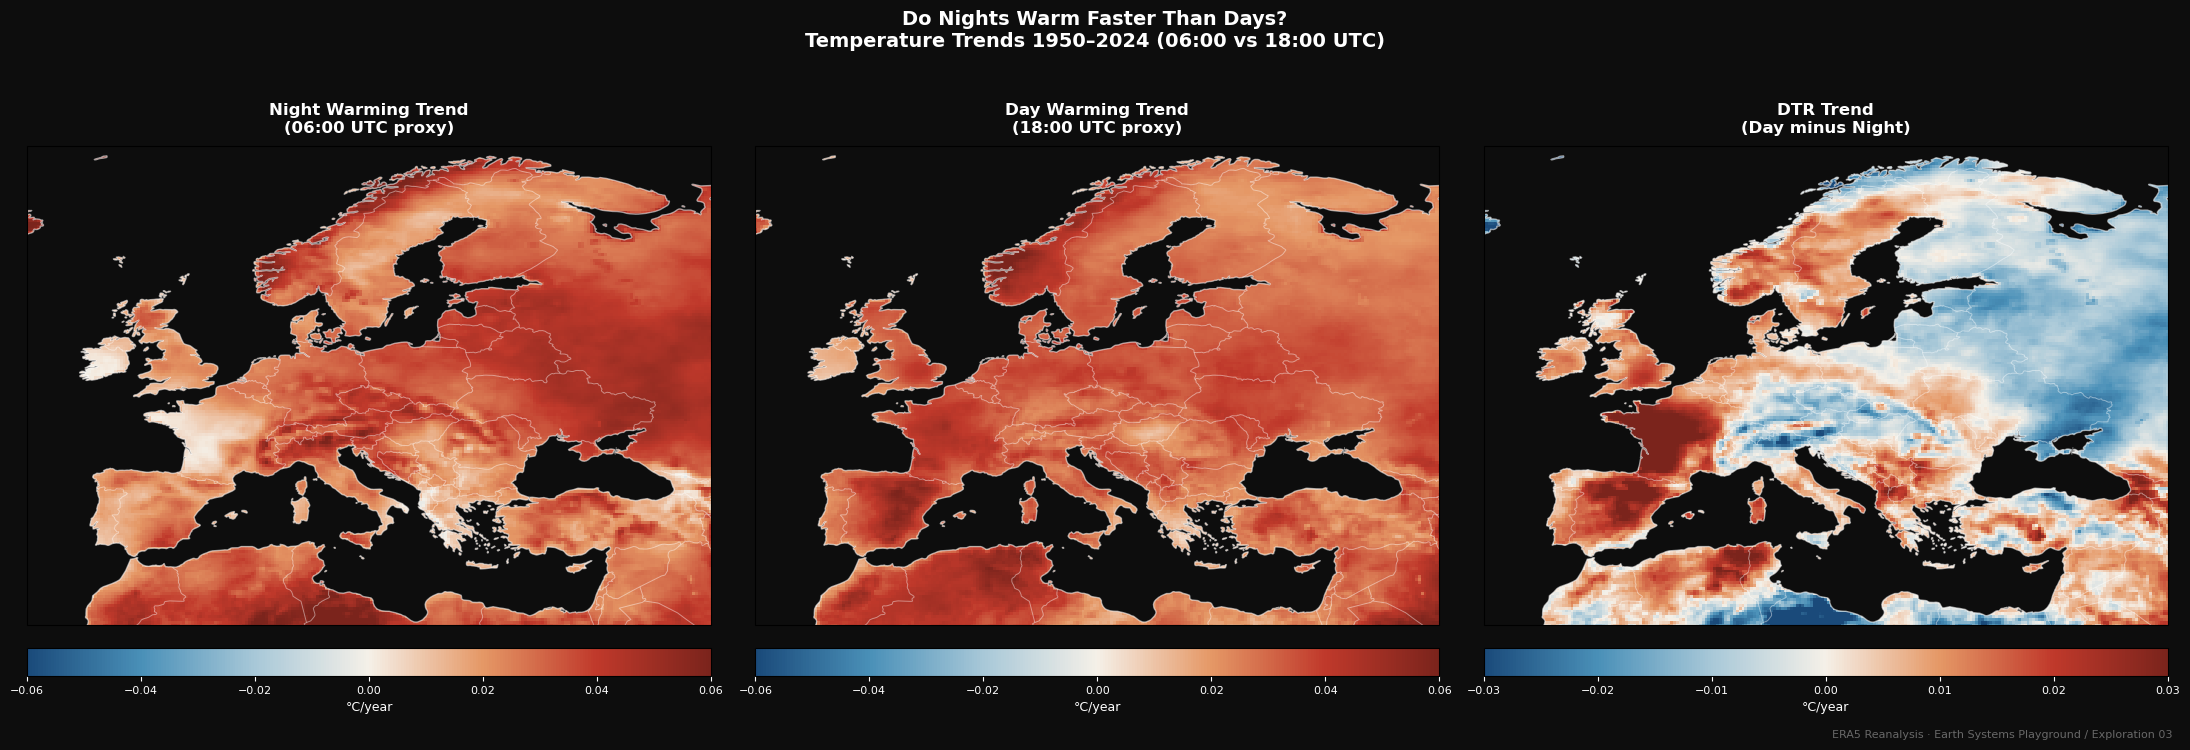

In [11]:
# ─── 7. MAPS ───────────────────────────────────────────────────────────────
print("\nPlotting maps...")

colors_div = ["#1a4a7a", "#4a90b8", "#a8c8d8", "#f5f0e8", "#e59866", "#c0392b", "#7b241c"]
cmap_div = LinearSegmentedColormap.from_list("dtr", colors_div)

fig, axes = plt.subplots(
    1, 3, figsize=(22, 7),
    subplot_kw={"projection": ccrs.PlateCarree()}
)
fig.patch.set_facecolor("#0d0d0d")

panels = [
    (trend_night, "Night Warming Trend\n(06:00 UTC proxy)", 0.06),
    (trend_day,   "Day Warming Trend\n(18:00 UTC proxy)",   0.06),
    (trend_dtr,   "DTR Trend\n(Day minus Night)",           0.03),
]
for ax, (d, title, vlim) in zip(axes, panels):
    ax.set_facecolor("#0d0d0d")
    ax.set_extent([-15, 45, 30, 72], crs=ccrs.PlateCarree())

    im = ax.pcolormesh(
        ds_all.longitude, ds_all.latitude, d,
        cmap=cmap_div, vmin=-vlim, vmax=vlim,
        transform=ccrs.PlateCarree()
    )
    ax.add_feature(cfeature.COASTLINE, linewidth=1.0, color="#ffffff90")
    ax.add_feature(cfeature.BORDERS,   linewidth=0.7, color="#ffffff70")
    ax.add_feature(cfeature.OCEAN, facecolor="#0d0d0d", zorder=1)

    ax.set_title(title, color="white", fontsize=12, fontweight="bold", pad=10)

    cbar = plt.colorbar(im, ax=ax, orientation="horizontal",
                        pad=0.04, fraction=0.05, aspect=25)
    cbar.set_label("°C/year", color="white", fontsize=9)
    cbar.ax.xaxis.set_tick_params(color="white")
    plt.setp(cbar.ax.xaxis.get_ticklabels(), color="white", fontsize=8)

fig.suptitle(
    "Do Nights Warm Faster Than Days?\nTemperature Trends 1950–2024 (06:00 vs 18:00 UTC)",
    color="white", fontsize=14, fontweight="bold", y=1.02
)
fig.text(0.99, -0.02,
         "ERA5 Reanalysis · Earth Systems Playground / Exploration 03",
         color="#ffffff60", fontsize=8, ha="right")

plt.tight_layout()
plt.savefig("D:/ex03/exploration_03_dtr_maps.png", dpi=150,
            bbox_inches="tight", facecolor="#0d0d0d")
plt.show()


Plotting city time series...


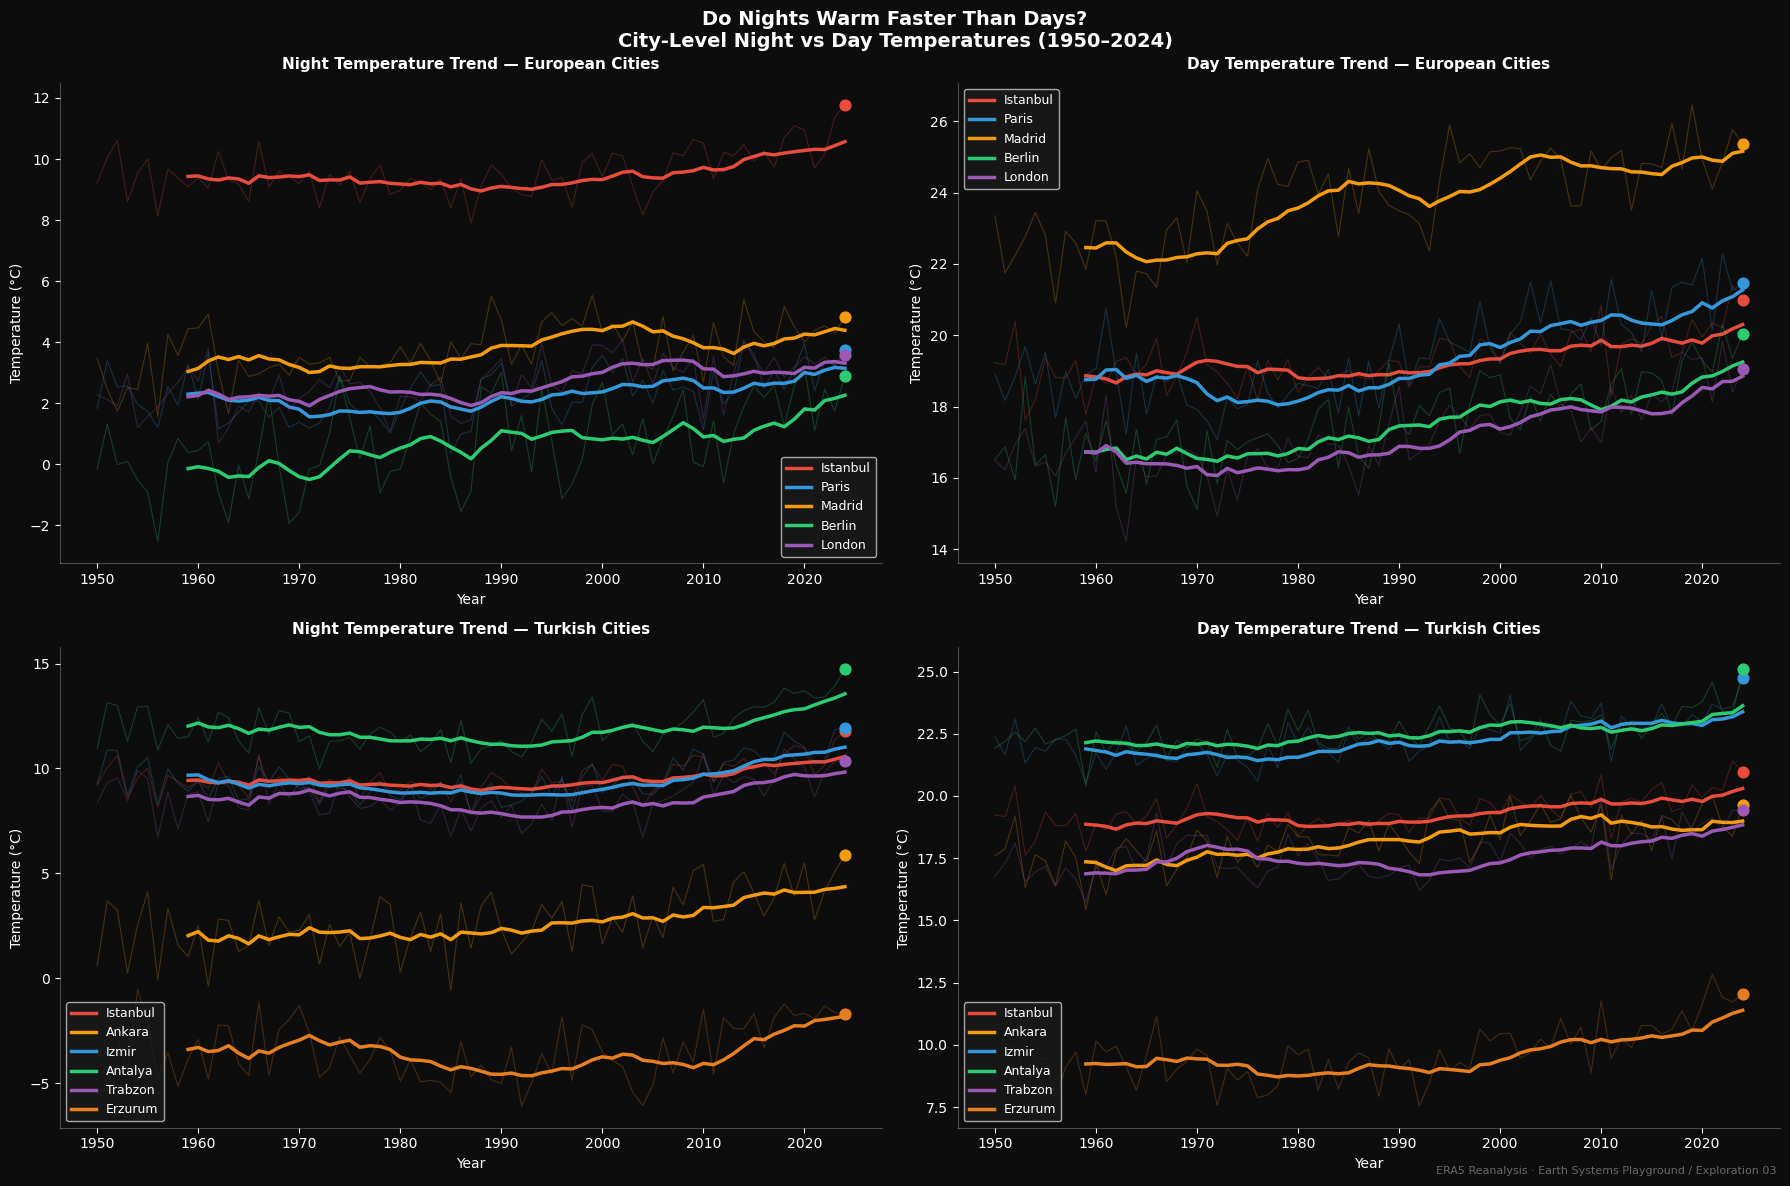


All done!


In [12]:
# ─── 8. CITY TIME SERIES ───────────────────────────────────────────────────
print("\nPlotting city time series...")

cities_eu = {
    "Istanbul": {"lat": 41.0, "lon": 29.0, "color": "#e74c3c"},
    "Paris":    {"lat": 48.8, "lon":  2.3, "color": "#3498db"},
    "Madrid":   {"lat": 40.4, "lon": -3.7, "color": "#f39c12"},
    "Berlin":   {"lat": 52.5, "lon": 13.4, "color": "#2ecc71"},
    "London":   {"lat": 51.5, "lon": -0.1, "color": "#9b59b6"},
}

cities_tr = {
    "Istanbul": {"lat": 41.0, "lon": 29.0, "color": "#e74c3c"},
    "Ankara":   {"lat": 39.9, "lon": 32.8, "color": "#f39c12"},
    "Izmir":    {"lat": 38.4, "lon": 27.1, "color": "#3498db"},
    "Antalya":  {"lat": 36.9, "lon": 30.7, "color": "#2ecc71"},
    "Trabzon":  {"lat": 41.0, "lon": 39.7, "color": "#9b59b6"},
    "Erzurum":  {"lat": 39.9, "lon": 41.3, "color": "#e67e22"},
}

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.patch.set_facecolor("#0d0d0d")

panel_config = [
    (axes[0,0], cities_eu, night_annual, "Night Temperature Trend — European Cities"),
    (axes[0,1], cities_eu, day_annual,   "Day Temperature Trend — European Cities"),
    (axes[1,0], cities_tr, night_annual, "Night Temperature Trend — Turkish Cities"),
    (axes[1,1], cities_tr, day_annual,   "Day Temperature Trend — Turkish Cities"),
]

for ax, cities, data, title in panel_config:
    ax.set_facecolor("#0d0d0d")

    for city, info in cities.items():
        ts = data.sel(
            latitude=info["lat"],
            longitude=info["lon"],
            method="nearest"
        ).values

        ax.plot(years, ts, color=info["color"], alpha=0.25, linewidth=0.8)
        smoothed = np.convolve(ts, np.ones(10)/10, mode="valid")
        ax.plot(years[9:], smoothed, color=info["color"],
                linewidth=2.5, label=city)
        ax.scatter(years[-1], ts[-1], color=info["color"], s=60, zorder=5)

    ax.set_facecolor("#0d0d0d")
    ax.set_xlabel("Year", color="white", fontsize=10)
    ax.set_ylabel("Temperature (°C)", color="white", fontsize=10)
    ax.set_title(title, color="white", fontsize=11, fontweight="bold", pad=10)
    ax.tick_params(colors="white")
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color("#ffffff40")
    ax.legend(facecolor="#1a1a1a", labelcolor="white", framealpha=0.8, fontsize=9)

fig.suptitle(
    "Do Nights Warm Faster Than Days?\nCity-Level Night vs Day Temperatures (1950–2024)",
    color="white", fontsize=14, fontweight="bold"
)
fig.text(0.99, 0.01,
         "ERA5 Reanalysis · Earth Systems Playground / Exploration 03",
         color="#ffffff60", fontsize=8, ha="right")

plt.tight_layout()
plt.savefig("D:/ex03/exploration_03_cities.png", dpi=150,
            bbox_inches="tight", facecolor="#0d0d0d")
plt.show()

print("\nAll done!")

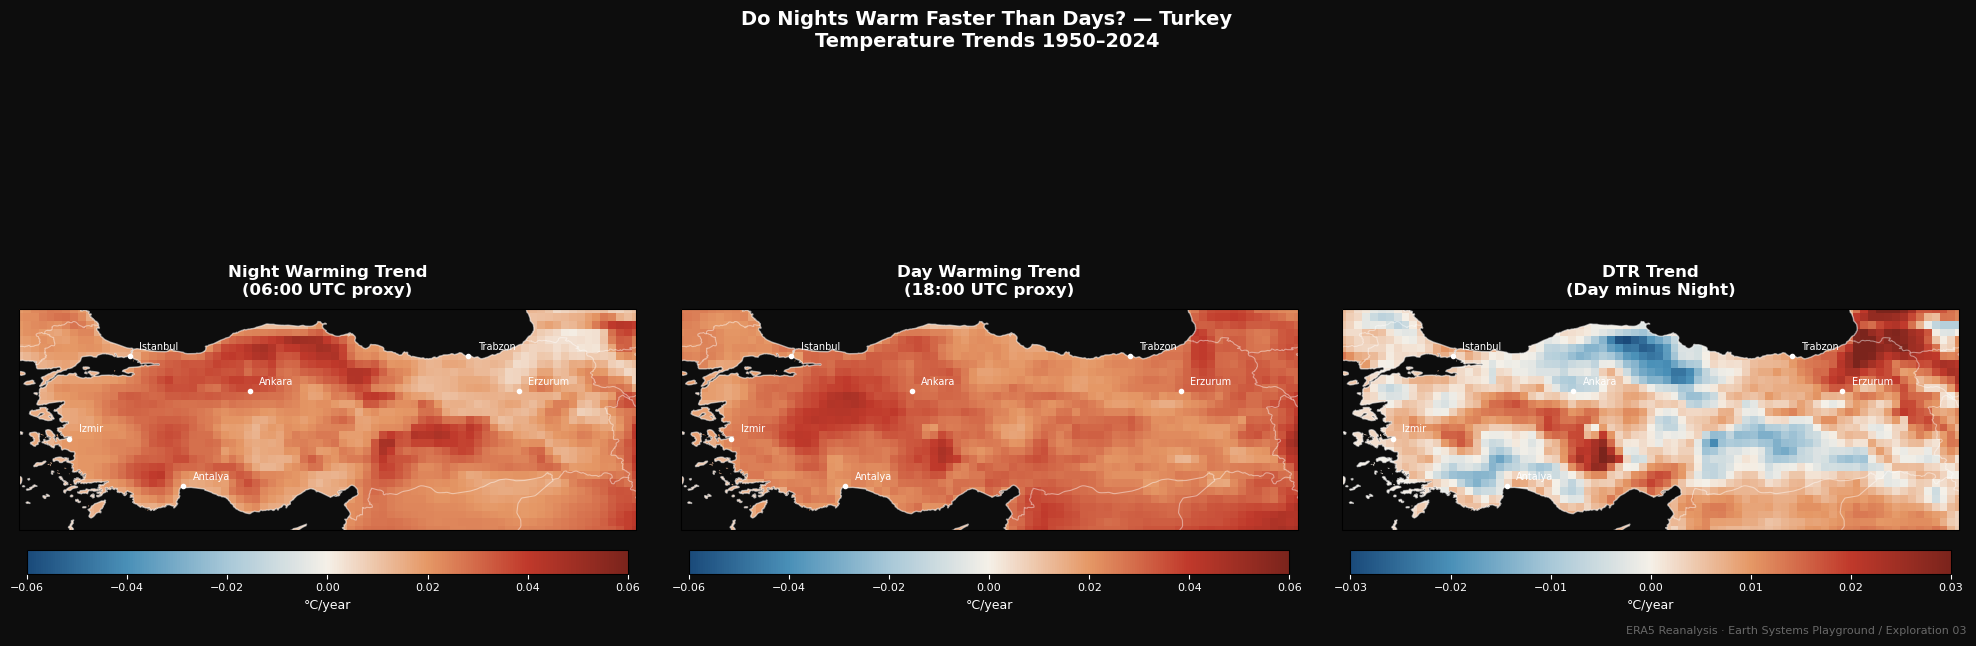

Turkey zoom saved!


In [13]:
fig, axes = plt.subplots(
    1, 3, figsize=(20, 6),
    subplot_kw={"projection": ccrs.PlateCarree()}
)
fig.patch.set_facecolor("#0d0d0d")

panels = [
    (trend_night, "Night Warming Trend\n(06:00 UTC proxy)", 0.06),
    (trend_day,   "Day Warming Trend\n(18:00 UTC proxy)",   0.06),
    (trend_dtr,   "DTR Trend\n(Day minus Night)",           0.03),
]

for ax, (d, title, vlim) in zip(axes, panels):
    ax.set_facecolor("#0d0d0d")
    ax.set_extent([25.5, 45.0, 35.5, 42.5], crs=ccrs.PlateCarree())

    im = ax.pcolormesh(
        ds_all.longitude, ds_all.latitude, d,
        cmap=cmap_div, vmin=-vlim, vmax=vlim,
        transform=ccrs.PlateCarree()
    )
    ax.add_feature(cfeature.COASTLINE, linewidth=1.0, color="#ffffff90")
    ax.add_feature(cfeature.BORDERS,   linewidth=0.8, color="#ffffff70")
    ax.add_feature(cfeature.OCEAN, facecolor="#0d0d0d", zorder=1)

    for city, info in cities_tr.items():
        ax.plot(info["lon"], info["lat"], "o", color="white",
                markersize=3, transform=ccrs.PlateCarree(), zorder=5)
        ax.text(info["lon"]+0.3, info["lat"]+0.2, city, color="white",
                fontsize=7, transform=ccrs.PlateCarree(), zorder=5)

    ax.set_title(title, color="white", fontsize=12, fontweight="bold", pad=10)

    cbar = plt.colorbar(im, ax=ax, orientation="horizontal",
                        pad=0.04, fraction=0.05, aspect=25)
    cbar.set_label("°C/year", color="white", fontsize=9)
    cbar.ax.xaxis.set_tick_params(color="white")
    plt.setp(cbar.ax.xaxis.get_ticklabels(), color="white", fontsize=8)

fig.suptitle(
    "Do Nights Warm Faster Than Days? — Turkey\nTemperature Trends 1950–2024",
    color="white", fontsize=14, fontweight="bold", y=1.02
)
fig.text(0.99, -0.02,
         "ERA5 Reanalysis · Earth Systems Playground / Exploration 03",
         color="#ffffff60", fontsize=8, ha="right")

plt.tight_layout()
plt.savefig("D:/ex03/exploration_03_turkey_zoom.png", dpi=150,
            bbox_inches="tight", facecolor="#0d0d0d")
plt.show()
print("Turkey zoom saved!")

In [14]:
# Seasonal DTR trends
seasons = {
    "Summer (Jun–Aug)": [6, 7, 8],
    "Winter (Dec–Feb)": [12, 1, 2],
    "Spring (Mar–May)": [3, 4, 5],
    "Autumn (Sep–Nov)": [9, 10, 11],
}

seasonal_dtr_trends = {}

for season_name, months in seasons.items():
    night_s = t_night_monthly.sel(
        valid_time=t_night_monthly.valid_time.dt.month.isin(months)
    ).resample(valid_time="YE").mean()

    day_s = t_day_monthly.sel(
        valid_time=t_day_monthly.valid_time.dt.month.isin(months)
    ).resample(valid_time="YE").mean()

    dtr_s = day_s - night_s
    trend_s = np.full((n_lat, n_lon), np.nan)

    for i in range(n_lat):
        for j in range(n_lon):
            slope, _, _, _, _ = stats.linregress(years, dtr_s.values[:, i, j])
            trend_s[i, j] = slope

    seasonal_dtr_trends[season_name] = trend_s
    print(f"{season_name}: {trend_s.min():.4f} to {trend_s.max():.4f}")

print("Seasonal trends done!")

Summer (Jun–Aug): -0.0556 to 0.0762
Winter (Dec–Feb): -0.1494 to 0.0672
Spring (Mar–May): -0.1318 to 0.0890
Autumn (Sep–Nov): -0.0713 to 0.0470
Seasonal trends done!


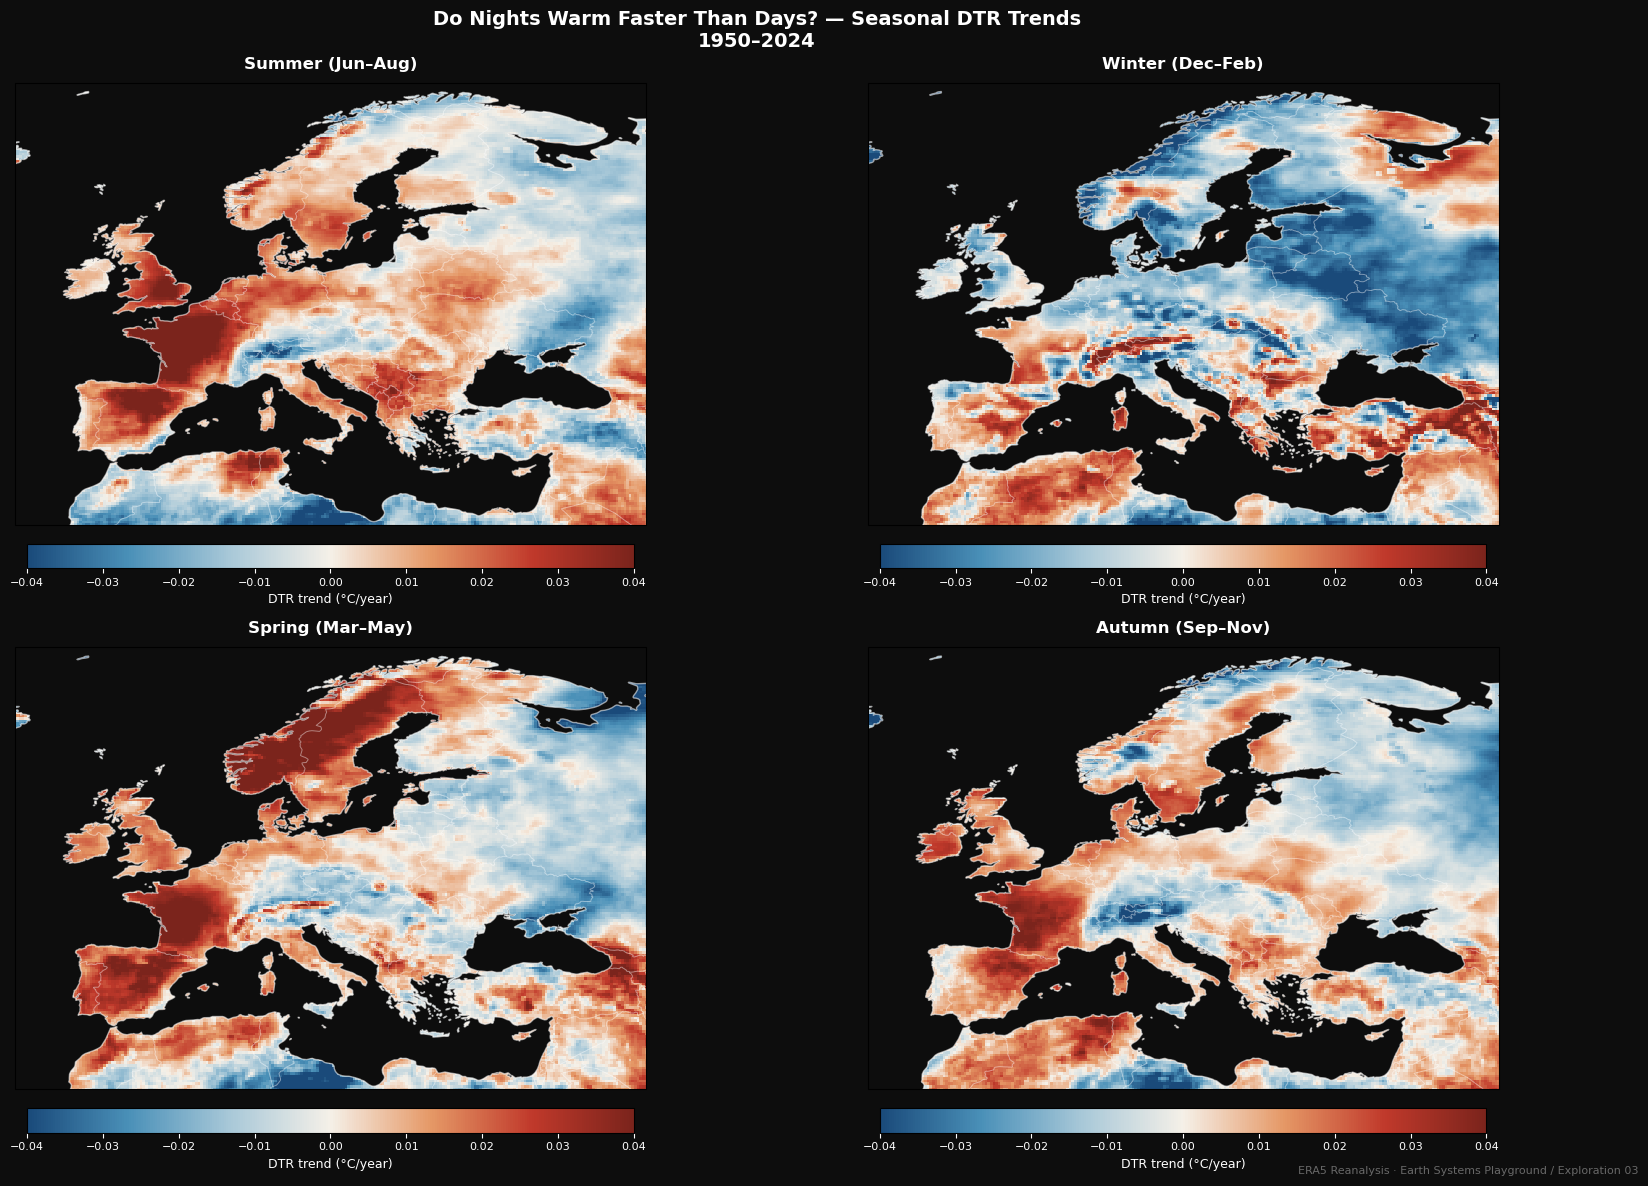

Seasonal DTR saved!


In [15]:
fig, axes = plt.subplots(
    2, 2, figsize=(18, 12),
    subplot_kw={"projection": ccrs.PlateCarree()}
)
fig.patch.set_facecolor("#0d0d0d")

for ax, (season_name, d) in zip(axes.flat, seasonal_dtr_trends.items()):
    ax.set_facecolor("#0d0d0d")
    ax.set_extent([-15, 45, 30, 72], crs=ccrs.PlateCarree())

    im = ax.pcolormesh(
        ds_all.longitude, ds_all.latitude, d,
        cmap=cmap_div, vmin=-0.04, vmax=0.04,
        transform=ccrs.PlateCarree()
    )
    ax.add_feature(cfeature.COASTLINE, linewidth=1.0, color="#ffffff90")
    ax.add_feature(cfeature.BORDERS,   linewidth=0.7, color="#ffffff70")
    ax.add_feature(cfeature.OCEAN, facecolor="#0d0d0d", zorder=1)

    ax.set_title(season_name, color="white", fontsize=12, fontweight="bold", pad=10)

    cbar = plt.colorbar(im, ax=ax, orientation="horizontal",
                        pad=0.04, fraction=0.05, aspect=25)
    cbar.set_label("DTR trend (°C/year)", color="white", fontsize=9)
    cbar.ax.xaxis.set_tick_params(color="white")
    plt.setp(cbar.ax.xaxis.get_ticklabels(), color="white", fontsize=8)

fig.suptitle(
    "Do Nights Warm Faster Than Days? — Seasonal DTR Trends\n1950–2024",
    color="white", fontsize=14, fontweight="bold"
)
fig.text(0.99, 0.01,
         "ERA5 Reanalysis · Earth Systems Playground / Exploration 03",
         color="#ffffff60", fontsize=8, ha="right")

plt.tight_layout()
plt.savefig("D:/ex03/exploration_03_seasonal_dtr.png", dpi=150,
            bbox_inches="tight", facecolor="#0d0d0d")
plt.show()
print("Seasonal DTR saved!")

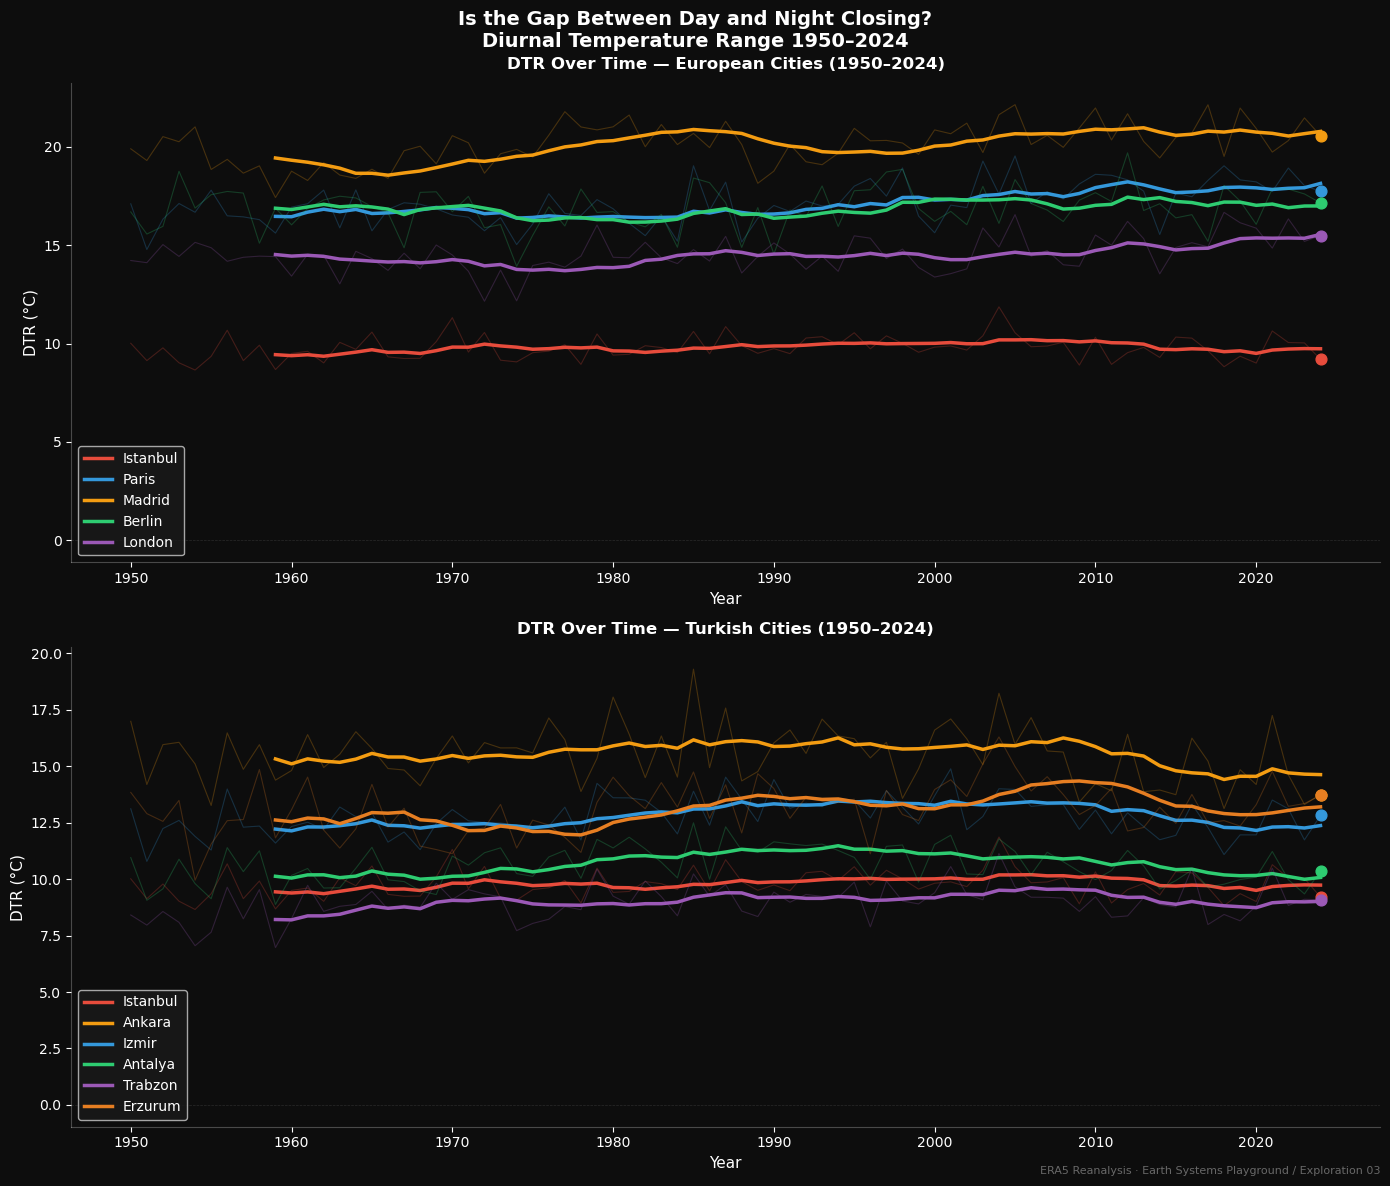

DTR cities saved!


In [16]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))
fig.patch.set_facecolor("#0d0d0d")

dtr_annual_vals = (day_annual - night_annual)

for ax, cities, title in zip(
    [ax1, ax2],
    [cities_eu, cities_tr],
    ["DTR Over Time — European Cities (1950–2024)",
     "DTR Over Time — Turkish Cities (1950–2024)"]
):
    ax.set_facecolor("#0d0d0d")

    for city, info in cities.items():
        ts = dtr_annual_vals.sel(
            latitude=info["lat"],
            longitude=info["lon"],
            method="nearest"
        ).values

        ax.plot(years, ts, color=info["color"], alpha=0.25, linewidth=0.8)
        smoothed = np.convolve(ts, np.ones(10)/10, mode="valid")
        ax.plot(years[9:], smoothed, color=info["color"],
                linewidth=2.5, label=city)
        ax.scatter(years[-1], ts[-1], color=info["color"], s=60, zorder=5)

    ax.set_xlabel("Year", color="white", fontsize=11)
    ax.set_ylabel("DTR (°C)", color="white", fontsize=11)
    ax.set_title(title, color="white", fontsize=12, fontweight="bold", pad=10)
    ax.tick_params(colors="white")
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color("#ffffff40")
    ax.legend(facecolor="#1a1a1a", labelcolor="white", framealpha=0.8, fontsize=10)
    ax.axhline(y=0, color="#ffffff20", linewidth=0.5, linestyle="--")

fig.suptitle(
    "Is the Gap Between Day and Night Closing?\nDiurnal Temperature Range 1950–2024",
    color="white", fontsize=14, fontweight="bold"
)
fig.text(0.99, 0.01,
         "ERA5 Reanalysis · Earth Systems Playground / Exploration 03",
         color="#ffffff60", fontsize=8, ha="right")

plt.tight_layout()
plt.savefig("D:/ex03/exploration_03_dtr_cities.png", dpi=150,
            bbox_inches="tight", facecolor="#0d0d0d")
plt.show()
print("DTR cities saved!")

Catchup decade range: 1960 to 2015


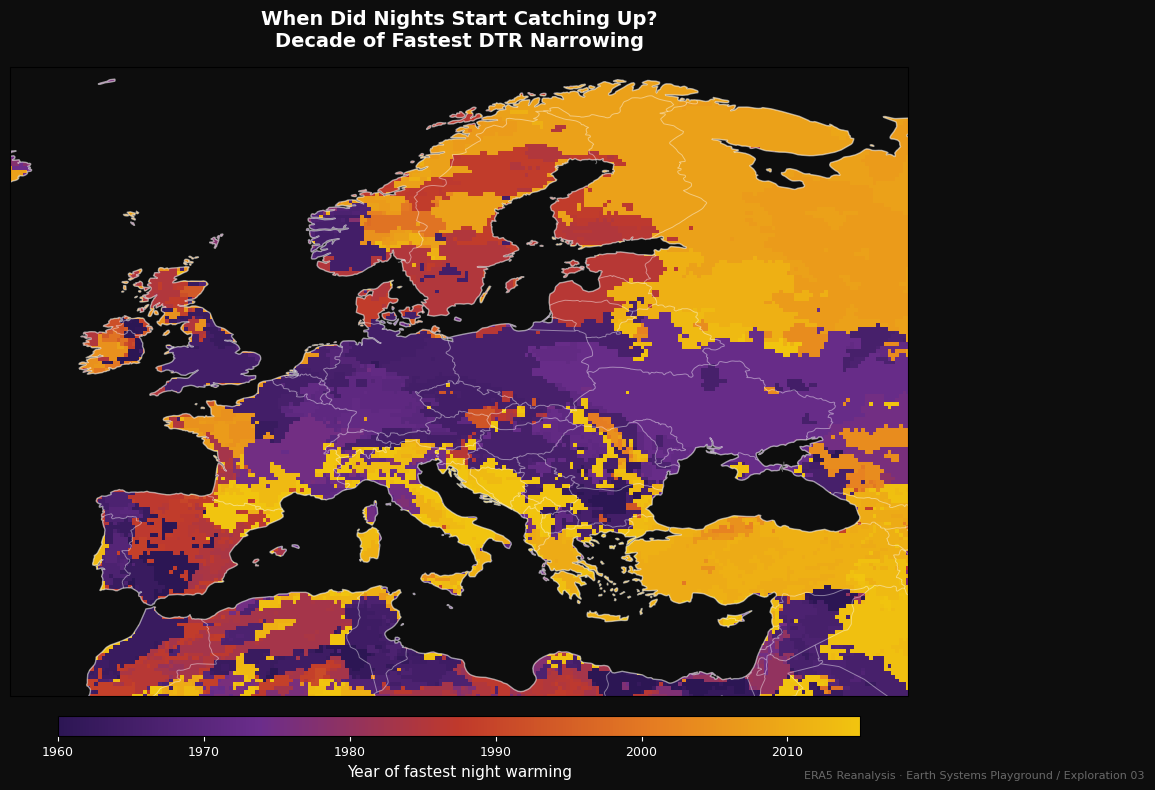

Catchup map saved!


In [18]:
# For each grid cell, find the decade with maximum DTR narrowing
# i.e. most negative DTR trend in 20-year rolling window

window = 20
n_windows = len(years) - window + 1
window_centers = years[window//2: window//2 + n_windows]

dtr_annual_vals_np = dtr_annual.values  # (75, n_lat, n_lon)

catchup_decade = np.full((n_lat, n_lon), np.nan)

for i in range(n_lat):
    for j in range(n_lon):
        min_slope = 0
        min_decade = np.nan
        for w in range(n_windows):
            slope, _, _, _, _ = stats.linregress(
                np.arange(window),
                dtr_annual_vals_np[w:w+window, i, j]
            )
            if slope < min_slope:
                min_slope = slope
                min_decade = window_centers[w]
        catchup_decade[i, j] = min_decade

print(f"Catchup decade range: {np.nanmin(catchup_decade):.0f} to {np.nanmax(catchup_decade):.0f}")

# Plot
fig, ax = plt.subplots(
    figsize=(14, 8),
    subplot_kw={"projection": ccrs.PlateCarree()}
)
fig.patch.set_facecolor("#0d0d0d")
ax.set_facecolor("#0d0d0d")
ax.set_extent([-15, 45, 30, 72], crs=ccrs.PlateCarree())

colors_decade = ["#2c1654", "#6b2d8b", "#c0392b", "#e67e22", "#f1c40f"]
cmap_decade = LinearSegmentedColormap.from_list("decade", colors_decade)

im = ax.pcolormesh(
    ds_all.longitude, ds_all.latitude, catchup_decade,
    cmap=cmap_decade, vmin=1960, vmax=2015,
    transform=ccrs.PlateCarree()
)
ax.add_feature(cfeature.COASTLINE, linewidth=1.0, color="#ffffff90")
ax.add_feature(cfeature.BORDERS,   linewidth=0.7, color="#ffffff70")
ax.add_feature(cfeature.OCEAN, facecolor="#0d0d0d", zorder=1)

cbar = plt.colorbar(im, ax=ax, orientation="horizontal",
                    pad=0.03, fraction=0.03, aspect=40)
cbar.set_label("Year of fastest night warming", color="white", fontsize=11)
cbar.ax.xaxis.set_tick_params(color="white")
plt.setp(cbar.ax.xaxis.get_ticklabels(), color="white", fontsize=9)

ax.set_title(
    "When Did Nights Start Catching Up?\nDecade of Fastest DTR Narrowing",
    color="white", fontsize=14, fontweight="bold", pad=15
)
fig.text(0.99, 0.02,
         "ERA5 Reanalysis · Earth Systems Playground / Exploration 03",
         color="#ffffff60", fontsize=8, ha="right")

plt.tight_layout()
plt.savefig("D:/ex03/exploration_03_catchup.png", dpi=150,
            bbox_inches="tight", facecolor="#0d0d0d")
plt.show()
print("Catchup map saved!")

Asymmetry range (clipped): 0.00 to 3.00
Mean asymmetry: 1.14
% of cells where nights warm faster (>1): 46.5%


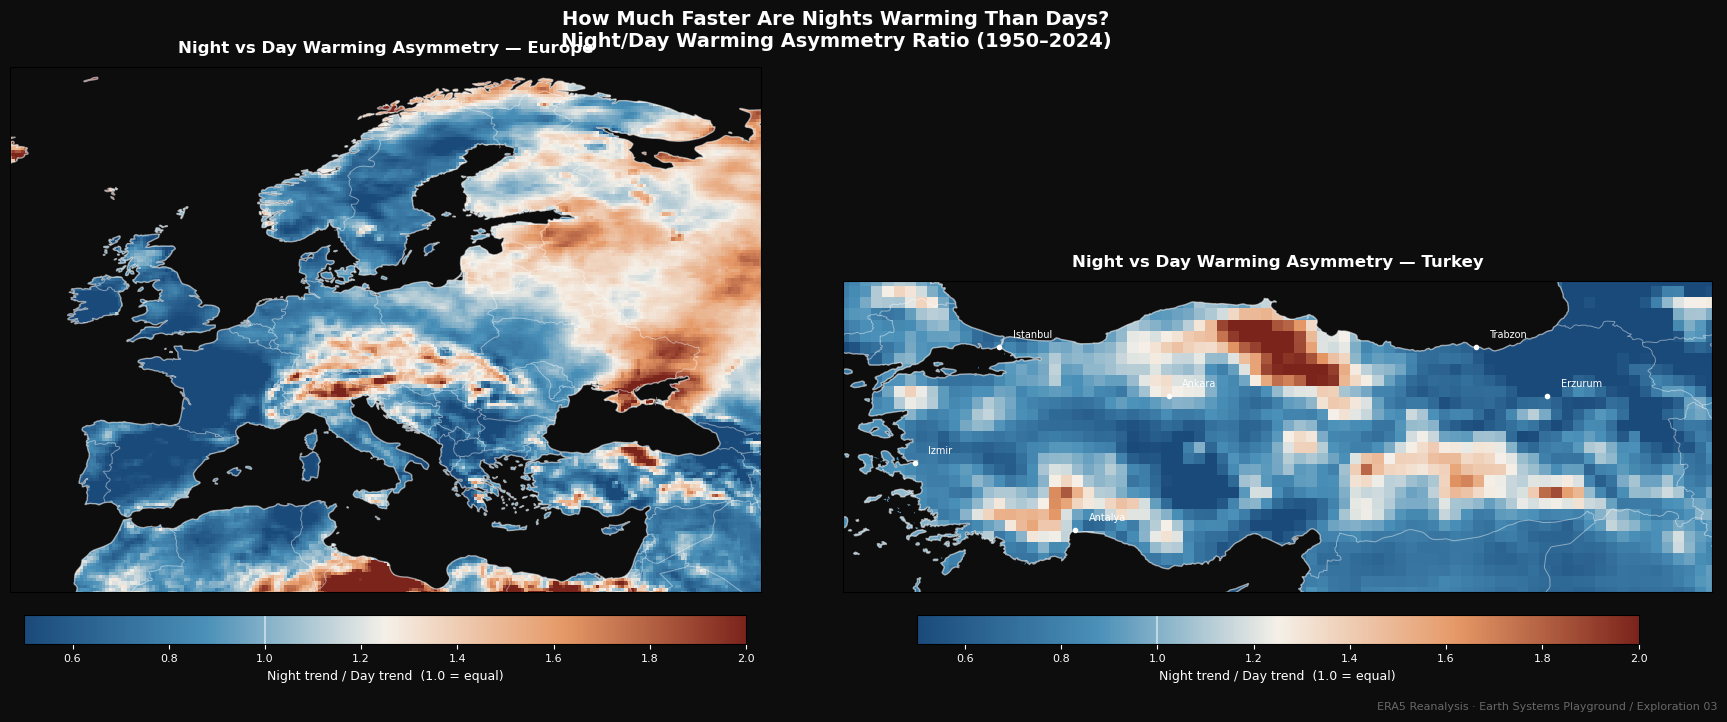

Asymmetry map saved!


In [19]:
# Asymmetry ratio: night warming / day warming
# Values > 1: nights warming faster
# Values < 1: days warming faster

# Avoid division by zero
with np.errstate(divide='ignore', invalid='ignore'):
    asymmetry = np.where(
        (trend_day > 0.001) | (trend_day < -0.001),  # avoid near-zero
        trend_night / trend_day,
        np.nan
    )

# Clip extremes for visualization
asymmetry_clipped = np.clip(asymmetry, 0, 3)

print(f"Asymmetry range (clipped): {np.nanmin(asymmetry_clipped):.2f} to {np.nanmax(asymmetry_clipped):.2f}")
print(f"Mean asymmetry: {np.nanmean(asymmetry_clipped):.2f}")
print(f"% of cells where nights warm faster (>1): {np.nanmean(asymmetry_clipped > 1)*100:.1f}%")

# Plot — Europe + Turkey side by side
fig, axes = plt.subplots(
    1, 2, figsize=(18, 7),
    subplot_kw={"projection": ccrs.PlateCarree()}
)
fig.patch.set_facecolor("#0d0d0d")

# Colormap: blue (days faster) → white (equal) → red (nights faster)
colors_asym = ["#1a4a7a", "#4a90b8", "#f5f0e8", "#e59866", "#7b241c"]
cmap_asym = LinearSegmentedColormap.from_list("asymmetry", colors_asym)

extents = [
    ([-15, 45, 30, 72], "Europe"),
    ([25.5, 45.0, 35.5, 42.5], "Turkey"),
]

for ax, (extent, title) in zip(axes, extents):
    ax.set_facecolor("#0d0d0d")
    ax.set_extent(extent, crs=ccrs.PlateCarree())

    im = ax.pcolormesh(
        ds_all.longitude, ds_all.latitude, asymmetry_clipped,
        cmap=cmap_asym, vmin=0.5, vmax=2.0,
        transform=ccrs.PlateCarree()
    )

    ax.add_feature(cfeature.COASTLINE, linewidth=1.0, color="#ffffff90")
    ax.add_feature(cfeature.BORDERS,   linewidth=0.7, color="#ffffff70")
    ax.add_feature(cfeature.OCEAN, facecolor="#0d0d0d", zorder=1)

    if title == "Turkey":
        for city, info in cities_tr.items():
            ax.plot(info["lon"], info["lat"], "o", color="white",
                    markersize=3, transform=ccrs.PlateCarree(), zorder=5)
            ax.text(info["lon"]+0.3, info["lat"]+0.2, city, color="white",
                    fontsize=7, transform=ccrs.PlateCarree(), zorder=5)

    ax.set_title(f"Night vs Day Warming Asymmetry — {title}",
                 color="white", fontsize=12, fontweight="bold", pad=10)

    cbar = plt.colorbar(im, ax=ax, orientation="horizontal",
                        pad=0.04, fraction=0.05, aspect=25)
    cbar.set_label("Night trend / Day trend  (1.0 = equal)", 
                   color="white", fontsize=9)
    cbar.ax.xaxis.set_tick_params(color="white")
    plt.setp(cbar.ax.xaxis.get_ticklabels(), color="white", fontsize=8)

    # Add reference line annotation
    cbar.ax.axvline(x=1.0, color="#ffffff80", linewidth=1.5)

fig.suptitle(
    "How Much Faster Are Nights Warming Than Days?\nNight/Day Warming Asymmetry Ratio (1950–2024)",
    color="white", fontsize=14, fontweight="bold"
)
fig.text(0.99, -0.02,
         "ERA5 Reanalysis · Earth Systems Playground / Exploration 03",
         color="#ffffff60", fontsize=8, ha="right")

plt.tight_layout()
plt.savefig("D:/ex03/exploration_03_asymmetry.png", dpi=150,
            bbox_inches="tight", facecolor="#0d0d0d")
plt.show()
print("Asymmetry map saved!")